In [58]:
#Data Preparation
import pandas as pd
df=pd.read_csv("C:/Users/DELL/Desktop/ml-assessment-Ashish_Kashid_bitsom_ba-2511333/data/q2_customers.csv")
df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [59]:
# Basic Check
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000


In [60]:
# Missing Values check
df.isnull().sum()

age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

In [61]:
#Data Feature Scaling
X=df
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Scaling is essential before applying K-means as K-means uses Euclidean distance to form Cluster. In our data Income value is very large compare to age value, if we do not scale the data then K-means is highly affected by Income value while age value is being ignored. So, cluster become biased and we didn't get proper details of business insights. If we do scaling before K-means all the features considered equally and form the meaningful cluster.

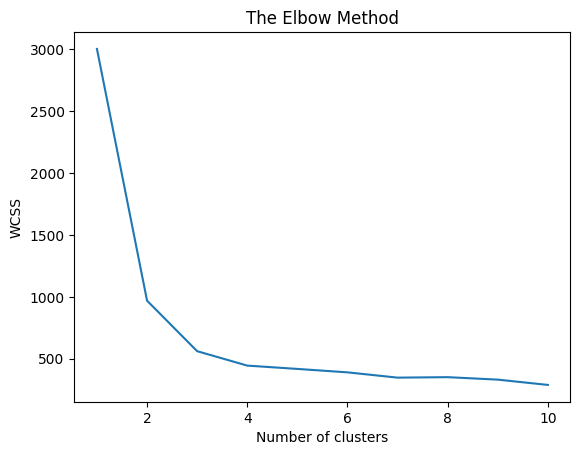

In [62]:
# Choosing K — Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


# From elbow method output we found optimal K value as 3.The above graph shows sharp dron in WCSS value from 1 to 2 as well as 2 to 3.After K=3 curve tends to become almost flat.

In [63]:
# K-means Clustering
#Fitting K-Means to the dataset
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
df['Cluster'] = y_kmeans
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,Cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [64]:
# Print cluster centroids as a DataFrame
centroids = kmeans.cluster_centers_
centroid_df = pd.DataFrame(centroids, columns=df.columns[:-1])  # Exclude 'Cluster' column
print(centroid_df)

        age  annual_spend  visits_per_month  basket_size  \
0 -1.094595     -1.036122          1.114284    -0.934278   
1  1.132214      1.235574         -1.106680     1.253260   
2 -0.004449     -0.168055         -0.041370    -0.290670   

   days_since_last_visit  num_categories_purchased  
0              -0.813494                 -1.045346  
1               1.125725                  1.172991  
2              -0.287579                 -0.095968  


# Interpretation of each cluster
+ve Value-Above Average
-ve Value-Below Average
# Cluster 0
+ve (Above Average)-visits_per_month
-ve (below Average)-age,annual_spend,basket_size,days_since_last_visit,num_categorises_purchased
Conclude-Younger customer who are visits frequently with smaller basket size, fewer categories purchase and less annual spend.
# Cluster 1
+ve (Above Average)-age,annual_spend,basket_size,days_since_last_visit,num_categorises_purchased,
-ve (below Average)-visits_per_month
Conclude-Older customer who visits less frequently but have higher spend, higher basket size with variety of product.
# Cluster 2
+ve (Above Average)-
-ve (below Average)-age,annual_spend,basket_size,days_since_last_visit,num_categorises_purchased,visits_per_month
Conclude-This is group of customer who are balanced across all the parameters.


In [65]:
# Dimensionality Reduction using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [66]:
#Explained variance ratio for Each PCA components
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio for Each PCA Component:", explained_variance)


Explained Variance Ratio for Each PCA Component: [0.83560354 0.05568764]


In [67]:
#Print the feature loadings (components) as a readable dataframe
components = pca.components_
components_df = pd.DataFrame(components, columns=df.columns[:-1])  # Exclude 'Cluster' column
print("Feature Loadings (Components):")
print(components_df)

Feature Loadings (Components):
        age  annual_spend  visits_per_month  basket_size  \
0  0.411569       0.42154         -0.410399     0.412012   
1 -0.259432      -0.03327          0.208318    -0.195402   

   days_since_last_visit  num_categories_purchased  
0               0.378582                  0.414017  
1               0.911194                 -0.140479  


# Interpretation of PCA
PC1=83.56%[0.83560354]
PC2=5.56% [0.05568764]
Total Variance=89.13% [PC1+PC2]
PC1 captures high proportion of total variance.
# Interpretation based on feature loadings
-PC1 highly affected by age,annual_spend,basket_size & num_categories purchased & have negative relation with visits_per_month, so PC1 Represents "High value but low frequency customers".
-PC2 highly affected by days_since_last_visit & visit_per_month, So PC2 represents "Low Value but high frequency customer".

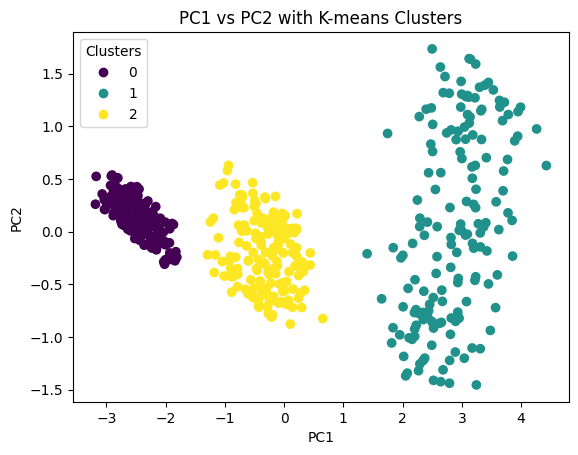

In [68]:
#Cluster Visualization
scatter=plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis')
plt.title('PC1 vs PC2 with K-means Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
handles, labels = scatter.legend_elements()
plt.legend(handles, labels, title="Clusters")
plt.show()

